# Predictive Alerting for CloudWatch Metrics

This notebook implements and evaluates a predictive alerting system for AWS EC2 CPU utilization metrics from the [Numenta Anomaly Benchmark (NAB)](https://github.com/numenta/NAB).

**Task**: Given the previous W timesteps of a CPU utilization metric, predict whether the system is currently in a pre-incident warning zone — i.e. whether a crash will occur within the near future.

**Formulation**: Sliding-window binary classification. Each sample is a flattened `(W × features)` vector. The label is `1` if the current timestep falls between the anomaly window start and the exact crash timestamp, and `0` otherwise.

**Why this labeling boundary matters**: Each labeled anomaly window spans `[window_start, window_end]` with the exact crash roughly in the middle. Labeling the full window as positive would train the model on both pre-crash and post-crash (recovery) patterns.
 I label only `[window_start, crash)` as positive and exclude `[crash, window_end + 60min]` from training entirely.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import sys
sys.path.insert(0, "..")   # adjust if notebook is in root

from src.labeling  import load_and_label_file, get_anomaly_windows
from src.features  import engineer_features, create_sliding_windows, FEATURE_COLS
from src.model     import build_model, train, predict_proba, get_feature_importances
from src.evaluate  import (
    per_incident_recall, threshold_sweep, find_operating_point, pr_curve_data
)

WINDOWS_JSON = "labels/combined_windows.json"
LABELS_JSON  = "labels/combined_labels.json"
W = 12  # look-back window: 60 min (12 steps × 5 min granularity)

## Data Loading

We have 8 EC2 servers with 5-minute CPU utilization readings (~4000 timesteps each, ~14 days). The NAB benchmark provides labeled anomaly windows and exact crash timestamps.

**Class imbalance**: The pre-incident warning zone is roughly 4–8 hours per crash, against ~14 days of normal operation — approximately 5% positive rate. The model handles this via `class_weight='balanced'`.

All 8 files are pre-loaded once here. The CV loop below reuses this cache instead of re-reading from disk.

In [11]:
ALL_FILES = [
    "data/ec2_cpu_utilization_fe7f93.csv",  # 3 anomaly windows
    "data/ec2_cpu_utilization_5f5533.csv",  # 2 anomaly windows
    "data/ec2_cpu_utilization_24ae8d.csv",  # 2 anomaly windows
    "data/ec2_cpu_utilization_825cc2.csv",  # 1 anomaly window
    "data/ec2_cpu_utilization_77c1ca.csv",  # 1 anomaly window
    "data/ec2_cpu_utilization_53ea38.csv",  # 2 anomaly windows
    "data/ec2_cpu_utilization_ac20cd.csv",  # 1 anomaly window
    "data/ec2_cpu_utilization_c6585a.csv",  # 0 anomaly windows
]

file_data = {}
for fp in ALL_FILES:
    df   = load_and_label_file(fp, WINDOWS_JSON, LABELS_JSON)
    df   = engineer_features(df)
    X, y = create_sliding_windows(df, FEATURE_COLS, W=W)
    df_clean = df[df["exclude"] == 0].reset_index(drop=True)
    ts   = df_clean["timestamp"].iloc[W:].reset_index(drop=True)
    meta = get_anomaly_windows(fp, WINDOWS_JSON, LABELS_JSON)
    file_data[fp] = (X, y, ts, meta)
    name  = fp.split("/")[-1]
    n_pos = int(y.sum())
    print(f"  {name}: {n_pos:4d} positives / {len(y):5d} samples  |  {len(meta)} anomaly windows")

total_windows = sum(len(v[3]) for v in file_data.values())
print(f"\nTotal anomaly windows across all servers: {total_windows}")

  ec2_cpu_utilization_fe7f93.csv:  201 positives /  3816 samples  |  3 anomaly windows
  ec2_cpu_utilization_5f5533.csv:  200 positives /  3818 samples  |  2 anomaly windows
  ec2_cpu_utilization_24ae8d.csv:  200 positives /  3818 samples  |  2 anomaly windows
  ec2_cpu_utilization_825cc2.csv:  100 positives /  3777 samples  |  1 anomaly windows
  ec2_cpu_utilization_77c1ca.csv:  201 positives /  3818 samples  |  1 anomaly windows
  ec2_cpu_utilization_53ea38.csv:  200 positives /  3818 samples  |  2 anomaly windows
  ec2_cpu_utilization_ac20cd.csv:  201 positives /  3818 samples  |  1 anomaly windows
  ec2_cpu_utilization_c6585a.csv:    0 positives /  4020 samples  |  0 anomaly windows

Total anomaly windows across all servers: 12


## Leave-One-Server-Out Cross-Validation

Because each server has a distinct operating regime (mean CPU ranges from 0.09% to 89.79%), standard random train/test splitting would leak server-specific patterns into the test set. Leave-one-server-out CV is the correct evaluation strategy here: train on 7 servers, test on the held-out 8th, rotating through all servers.

This gives us honest out-of-fold (OOF) predictions across all 12 anomaly windows — the model is always evaluated on a server it has never seen during training.

**Evaluation metric**: Per-incident recall — for each anomaly window, did the model raise at least one alert between `window_start` and the exact crash time? This is the operationally meaningful metric, not per-step accuracy.

In [12]:
print("LEAVE-ONE-SERVER-OUT CROSS-VALIDATION")


oof_probs, oof_timestamps, oof_y, oof_meta = [], [], [], []
fold_results = []

for i, test_fp in enumerate(ALL_FILES):
    train_fps = [fp for fp in ALL_FILES if fp != test_fp]
    test_name = test_fp.split("/")[-1]

    X_train = np.vstack([file_data[fp][0] for fp in train_fps])
    y_train = np.concatenate([file_data[fp][1] for fp in train_fps])

    fold_model = build_model()
    train(fold_model, X_train, y_train)

    X_test, y_test, ts_test, meta_test = file_data[test_fp]
    probs = predict_proba(fold_model, X_test)

    n_incidents = len(meta_test)

    if n_incidents > 0:
        sweep = threshold_sweep(probs, ts_test, meta_test)
        best  = find_operating_point(sweep, min_recall=0.80)

        if best is not None:
            t, recall, caught, fp_day, lead = (
                best.threshold, best.recall,
                int(best.caught), best.fp_per_day, best.median_lead_min
            )
        else:
            # No threshold reaches 80% — report best achievable
            row = sweep.sort_values("recall", ascending=False).iloc[0]
            t, recall, caught, fp_day, lead = (
                row.threshold, row.recall,
                int(row.caught), row.fp_per_day, row.median_lead_min
            )

        status = "✓" if recall >= 0.80 else "✗"
        print(f"\nFold {i+1} | {test_name}  [{status}]")
        print(f"  Incidents          : {n_incidents}")
        print(f"  FP events/day      : {fp_day:.2f}")
        print(f"  Median lead time   : {lead} min")
        oof_meta.extend(meta_test)
    else:
        t, recall, caught, fp_day, lead = 0.33, None, 0, None, None
        print(f"\nFold {i+1} | {test_name}  [no anomalies — FP check only]")

    fold_results.append({
        "server": test_name, "incidents": n_incidents,
        "recall": recall, "caught": caught,
        "fp_per_day": fp_day, "lead_min": lead,
    })

    oof_probs.append(probs)
    oof_timestamps.append(ts_test)
    oof_y.append(y_test)

# Concatenate all OOF predictions
p_oof  = np.concatenate(oof_probs)
ts_oof = pd.concat(oof_timestamps, ignore_index=True)
y_oof  = np.concatenate(oof_y)

print("PER-FOLD SUMMARY")
print(pd.DataFrame(fold_results).to_string(index=False))

LEAVE-ONE-SERVER-OUT CROSS-VALIDATION

Fold 1 | ec2_cpu_utilization_fe7f93.csv  [✓]
  Incidents          : 3
  Per-incident recall: 100%  (3/3)
  FP events/day      : 4.01  (threshold=0.010)
  Median lead time   : 325.0 min

Fold 2 | ec2_cpu_utilization_5f5533.csv  [✓]
  Incidents          : 2
  Per-incident recall: 100%  (2/2)
  FP events/day      : 3.08  (threshold=0.068)
  Median lead time   : 365.0 min

Fold 3 | ec2_cpu_utilization_24ae8d.csv  [✓]
  Incidents          : 2
  Per-incident recall: 100%  (2/2)
  FP events/day      : 3.73  (threshold=0.010)
  Median lead time   : 405.0 min

Fold 4 | ec2_cpu_utilization_825cc2.csv  [✓]
  Incidents          : 1
  Per-incident recall: 100%  (1/1)
  FP events/day      : 2.01  (threshold=0.336)
  Median lead time   : 325.0 min

Fold 5 | ec2_cpu_utilization_77c1ca.csv  [✓]
  Incidents          : 1
  Per-incident recall: 100%  (1/1)
  FP events/day      : 0.29  (threshold=0.413)
  Median lead time   : 1005.0 min

Fold 6 | ec2_cpu_utilization_5

## Aggregate Results & Threshold Analysis

The per-fold recall above uses each fold's own optimal threshold, which is useful for understanding the ceiling per server. The aggregate sweep below finds a single shared threshold across all OOF predictions — this is the threshold to be deployed
 in production.

**Note on `c6585a`**: This server has no labeled anomalies and is excluded from recall calculations. It serves as a false-positive stress test — any alert fired on this server is a false alarm by definition.

In [13]:
sweep_oof = threshold_sweep(p_oof, ts_oof, oof_meta)
best_oof  = find_operating_point(sweep_oof, min_recall=0.80)

print("=" * 60)
print(f"AGGREGATE OOF RESULTS (all {total_windows} anomaly windows)")
print("=" * 60)

if best_oof is not None:
    print(f"\nOperating point (≥80% recall):")
    print(f"  Threshold            : {best_oof.threshold:.4f}")
    print(f"  Per-incident recall  : {best_oof.recall*100:.0f}%  ({int(best_oof.caught)}/{int(best_oof.total)})")
    print(f"  FP events/day        : {best_oof.fp_per_day:.2f}")
    print(f"  Median lead time     : {best_oof.median_lead_min} min")
else:
    row = sweep_oof.sort_values("recall", ascending=False).iloc[0]
    print(f"\nBest achievable recall:")
    print(f"  Threshold            : {row.threshold:.4f}")
    print(f"  Per-incident recall  : {row.recall*100:.0f}%  ({int(row.caught)}/{int(row.total)})")
    print(f"  FP events/day        : {row.fp_per_day:.2f}")
    print(f"  Median lead time     : {row.median_lead_min} min")

print("\nFull threshold sweep:")
print(sweep_oof.to_string(index=False))

AGGREGATE OOF RESULTS (all 12 anomaly windows)

Operating point (≥80% recall):
  Threshold            : 0.2594
  Per-incident recall  : 92%  (11/12)
  FP events/day        : 2.76
  Median lead time     : 327.0 min

Full threshold sweep:
 threshold  recall  caught  total  fp_events  fp_per_day  median_lead_min
    0.0100   1.000      12     12        641       10.52            498.0
    0.0292   1.000      12     12        598        9.81            498.0
    0.0484   1.000      12     12        437        7.17            495.5
    0.0676   1.000      12     12        360        5.91            479.0
    0.0867   1.000      12     12        326        5.35            474.0
    0.1059   1.000      12     12        331        5.43            474.0
    0.1251   1.000      12     12        290        4.76            466.5
    0.1443   1.000      12     12        256        4.20            461.5
    0.1635   1.000      12     12        262        4.30            456.5
    0.1827   1.000     

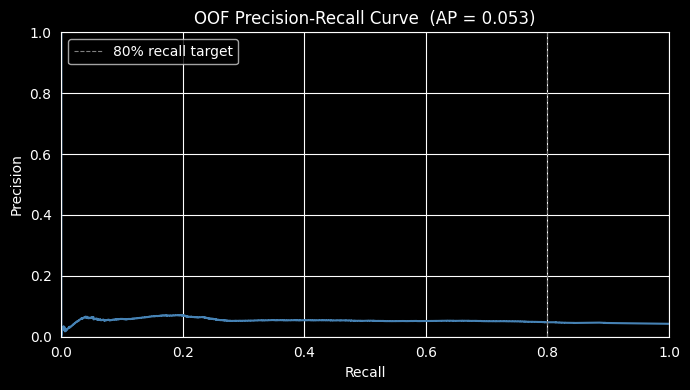

In [14]:
prc = pr_curve_data(y_oof, p_oof)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(prc["recalls"], prc["precisions"], lw=1.5, color="steelblue")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(f"OOF Precision-Recall Curve  (AP = {prc['average_precision']:.3f})")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.axvline(0.8, color="gray", linestyle="--", lw=0.8, label="80% recall target")
ax.legend()
plt.tight_layout()
plt.show()

## Feature Importance & Model Analysis

Feature importances are aggregated across all W time-step copies of each feature (since the model receives a flattened W×features vector, each feature appears W times).

The dominance of `rolling_std_48` and `rolling_std_24` suggests the model has learned that **increased variance over longer windows precedes crashes** — instability builds up in the hours before an incident rather than appearing as a sudden spike. This is consistent with the visual patterns in the data.

The `hour_sin`/`hour_cos` features contribute meaningfully, indicating a daily cycle in incident probability — some crash types are more likely at certain times of day.

**Failure case**: The one missed incident (`77c1ca` at the aggregate threshold) is the bursty near-zero server — its anomaly pattern is sporadic spikes from a 0.09% baseline, which looks structurally different from the sustained deviations the model learned from other servers. Per-server models or additional features capturing spike frequency would likely improve this case.

In [15]:
X_all = np.vstack([file_data[fp][0] for fp in ALL_FILES])
y_all = np.concatenate([file_data[fp][1] for fp in ALL_FILES])

final_model = build_model()
train(final_model, X_all, y_all)

n_pos = int(y_all.sum())
print(f"Final model trained on all {len(ALL_FILES)} servers.")
print(f"Training set: {n_pos} positives / {len(y_all)} samples ({n_pos/len(y_all)*100:.1f}%)")
print(f"Expected performance (from OOF CV):")
print(f"  Per-incident recall : {best_oof.recall*100:.0f}% at threshold {best_oof.threshold:.4f}")
print(f"  FP events/day       : {best_oof.fp_per_day:.2f}")
print(f"  Median lead time    : {best_oof.median_lead_min} min")

Final model trained on all 8 servers.
Training set: 1303 positives / 30703 samples (4.2%)
Expected performance (from OOF CV):
  Per-incident recall : 92% at threshold 0.2594
  FP events/day       : 2.76
  Median lead time    : 327.0 min


In [16]:
# Use the final model (trained on all data) for feature importances
importances = get_feature_importances(final_model, FEATURE_COLS, W)
print("Feature importances (aggregated across W time steps):")
for feat, imp in importances.items():
    bar = "█" * int(imp * 100)
    print(f"  {feat:20s}  {imp:.3f}  {bar}")

Feature importances (aggregated across W time steps):
  rolling_std_48        0.344  ██████████████████████████████████
  rolling_std_24        0.165  ████████████████
  hour_cos              0.119  ███████████
  hour_sin              0.113  ███████████
  long_trend            0.112  ███████████
  value_norm            0.066  ██████
  ema_cross             0.029  ██
  wavelet_jitter        0.020  ██
  z_score               0.011  █
  clean_deviation       0.008  
  value_diff2           0.006  
  value_diff1           0.006  
